# Actividad: buscando a juanga

🎯 Objetivo: Aplicar pruebas de hipótesis para el vector de medias en poblaciones normales multivariadas usando la prueba 
T^2 de Hotelling (para una y dos muestras), en un caso realista: distinguir billetes reales de falsos a partir de sus características.

1. Carga los datos y prepara las matrices de datos para realizar el análisis.

* Cuando trabajamos con datos multivariados una de las tareas más comunes e importantes es la reducción de dimensionalidad, más adelante hablaremos sobre una de las técnicas más populares para realizar este proceso. Sin embargo, también podemos reducir la dimensión de nuestro conjunto de datos mediante feature selection.

2. Calcula la matriz de correlación sobre todos los datos, es decir, toma la muestra de los billetes reales y sospechosos.

3. Realiza una selección de variables utilizando la matriz de correlación tomando como umbral 0.7, es decir, toma aquellas variables con 
∣r∣ > 0.70. ¿Qué variables seleccionarías?

4. Utiliza la función GenericUnivariateSelect() de sklearn.feature_selection en conjunto con la función pearsonr() del módulo stats de scipy para seleccionar 6 variables usando el coeficiente de correlación de Pearson y el p-value asociado a la prueba de hipótesis cuya hipótesis nula establece que las dos variables no están correlacionadas (es decir, que su correlación poblacional es cero).

5. Con base en la selección de variables que realizaste en el ejercicio anterior, lleva a cabo una prueba de hipótesis para verificar si los billetes falsos difieren de los verdaderos en sus características. ¿Cuál es la conclusión de la prueba en el contexto de los datos?

6. Utiliza las variables que has seleccionado y el vector de medias muestral de los billetes reales como media hipotética para llevar a cabo una prueba T^2 de Hotelling sobre la muestra de billetes sospechosos. ¿El resultado es consistente con lo que obtuviste anteriormente?

7. Elabora un profile plot para determinar qué variables se encuentran por arriba o por debajo del valor medio hipotético.

8. Con base en todos los resultados que has obtenido, ¿cuál crees que sea la característica más relevante de un billete que ayude a detectar un billete falso?

In [2]:
import pandas as pd 
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import GenericUnivariateSelect
from scipy.stats import pearsonr


1. Carga los datos y prepara las matrices de datos para realizar el análisis.

In [3]:
# Carga los datos y prepara las matrices de datos para realizar el análisis.

df = pd.read_csv('../data/bank_notes.csv')
df.head()

,type,length,thick,left,right,width,bottom,top,weight,diag
0,sample,214.8,0.38,131.0,131.1,9.43,9.0,9.7,96.6,141.0
1,sample,214.6,0.29,129.7,129.7,6.30,8.1,9.5,20.2,141.7
2,sample,214.8,0.99,129.7,129.7,7.13,8.7,9.6,4.5,142.2
3,sample,214.8,0.14,129.7,129.6,7.46,7.5,10.4,94.2,142.0
4,sample,215.0,0.93,129.6,129.7,7.67,10.4,7.7,68.4,141.8


Cambiamos las etiquetas de la columna 'type' de categóricas a numéricas y eliminamos las etiquetas. También dividimos el conjunto de datos en dos: uno para los billetes reales y otro para los billetes falsos.

In [4]:
# convertir la variables de la columna type de categórica en numérica; sample = 0 y suspect = 1
df['type'] = df['type'].map({'sample': 0, 'suspect': 1})

# quitamos la columna de type
X = df.drop(columns=['type']) 

# billetes reales
df_real = X[df['type'] == 0]   

# billetes falsos
df_fake = X[df['type'] == 1]   

2. Calcula la matriz de correlación sobre todos los datos, es decir, toma la muestra de los billetes reales y sospechosos.

In [5]:
# Calcula la matriz de correlación sobre todos los datos, es decir, toma la muestra de los billetes reales y sospechosos.

corr = X.corr()
corr 

,length,thick,left,right,width,bottom,top,weight,diag
length,1.000000,-0.072769,0.231293,0.151763,-0.035644,-0.189801,-0.061321,0.076210,0.194301
thick,-0.072769,1.000000,-0.131513,0.011808,-0.031475,-0.003266,-0.075242,-0.030462,0.062584
left,0.231293,-0.131513,1.000000,0.743263,-0.022770,0.413781,0.362350,0.102147,-0.503229
right,0.151763,0.011808,0.743263,1.000000,-0.040533,0.486758,0.400670,0.124121,-0.516476
width,-0.035644,-0.031475,-0.022770,-0.040533,1.000000,-0.094953,-0.028329,0.116881,0.060217
bottom,-0.189801,-0.003266,0.413781,0.486758,-0.094953,1.000000,0.141851,-0.065335,-0.622983
top,-0.061321,-0.075242,0.362350,0.400670,-0.028329,0.141851,1.000000,0.129223,-0.594045
weight,0.076210,-0.030462,0.102147,0.124121,0.116881,-0.065335,0.129223,1.000000,-0.032003
diag,0.194301,0.062584,-0.503229,-0.516476,0.060217,-0.622983,-0.594045,-0.032003,1.000000


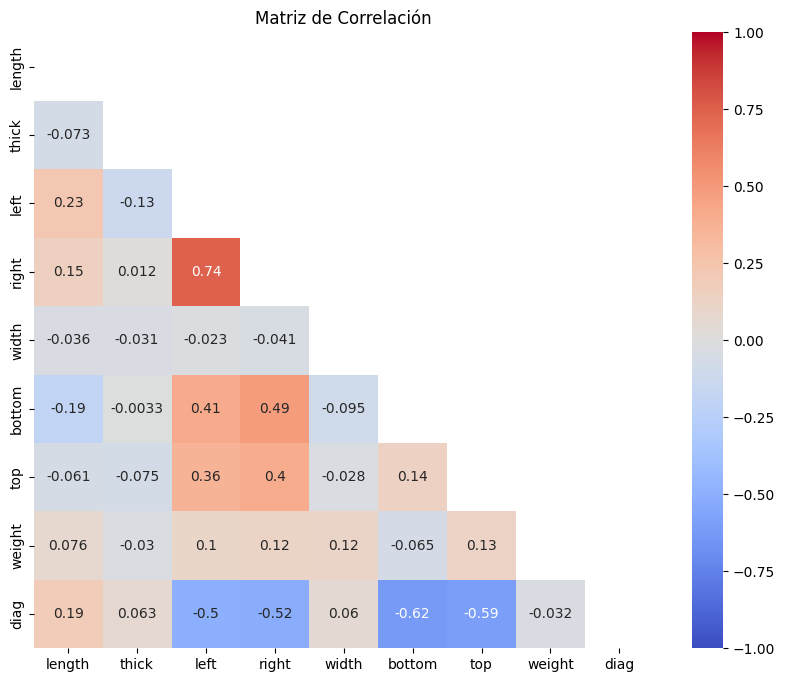

In [6]:
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

Basado en la matriz de correlación, las variables con correlacion mayor a 0.7 son: left, right, bottom y diag.

3. Realiza una selección de variables utilizando la matriz de correlación tomando como umbral 0.7, es decir, toma aquellas variables con 
∣r∣ > 0.70. ¿Qué variables seleccionarías?

In [7]:
# Realiza una selección de variables utilizando la matriz de correlación tomando como umbral 0.7, es decir, toma aquellas variables con ∣r∣ > 0.70. ¿Qué variables seleccionarías?
# selecciona las variables con correlación mayor a 0.7
r = 0.7

# Filtrar pares con |r| > 0.7
for col in corr.columns: # nombre de las variables en las columnas
    for idx in corr.index: # nombre de las variables en las filas
        if col != idx and abs(corr.loc[col, idx]) > r:
            print(f"{col} con {idx} : {corr.loc[col, idx]:.3f}")

left con right : 0.743
right con left : 0.743


Basandome en el umbral, podemos ver que solo las variables left y right tienen relación, más no obstante considero que bottom/diag, top/diag, diag/left , diag/right y bottom/right también tienen una relación fuerte.

4. Utiliza la función GenericUnivariateSelect() de sklearn.feature_selection en conjunto con la función pearsonr() del módulo stats de scipy para seleccionar 6 variables usando el coeficiente de correlación de Pearson y el p-value asociado a la prueba de hipótesis cuya hipótesis nula establece que las dos variables no están correlacionadas (es decir, que su correlación poblacional es cero).

In [8]:
# Función
def pearson_score(X_, y_):
    scores = np.zeros(X_.shape[1])
    for i in range(X_.shape[1]):
        r, _ = pearsonr(X_[:, i], y_)
        scores[i] = abs(r)
    return scores, np.ones(X_.shape[1])

def score_func(X_, y_):
    return pearson_score(X_, y_)

# definir y
y = df['type'].values

# Seleccionar mejores
selector = GenericUnivariateSelect(score_func=score_func, mode='k_best', param=6)
selector.fit(X.values, y)

selected_features = X.columns[selector.get_support()].tolist()
print("6 variables seleccionadas:", selected_features)

6 variables seleccionadas: ['length', 'left', 'right', 'bottom', 'top', 'diag']


5. Con base en la selección de variables que realizaste en el ejercicio anterior, lleva a cabo una prueba de hipótesis para verificar si los billetes falsos difieren de los verdaderos en sus características. ¿Cuál es la conclusión de la prueba en el contexto de los datos?

In [9]:
from scipy.stats import ttest_ind
results = []

for col in selected_features:
    stat, p = ttest_ind(df_real[col], df_fake[col], equal_var=False) #Welch porqué de antemano sé que no tienen varianzas iguales entre ambos grupos
    results.append((col, stat, p))

ttest_df = pd.DataFrame(results, columns=['Variable','t_stat','p_value'])
print(ttest_df)

  Variable     t_stat       p_value
0   length   2.787902  5.826920e-03
1     left  -8.030541  1.299591e-13
2    right -10.196167  8.653755e-20
3   bottom -17.092541  1.187265e-37
4      top -10.620160  3.863090e-21
5     diag  28.914855  2.588777e-71


$$H_{0}:\mu_{suspect} = \mu_{0}, H_{a}:\mu_{suspect} \neq \mu_{0}$$
donde $\mu_{0} = \mu_{sample}$

Se rechaza la hipótesis nula, lo que significa que las medias de estas variables en efecto difieren entre poblaciones.

6. Utiliza las variables que has seleccionado y el vector de medias muestral de los billetes reales como media hipotética para llevar a cabo una prueba T^2 de Hotelling sobre la muestra de billetes sospechosos. ¿El resultado es consistente con lo que obtuviste anteriormente?

In [10]:
def HotellingsT2Test(X, Y):
    '''Realiza la prueba T2 de Hotelling para dos muestras

       Parámetros
       ----------
       X: pd.DataFrame
           Matriz de datos de la primera población
       Y: pd.DataFrame
           Matriz de datos de la segunda población

       Output
       ------
       statistic: float
           Valor de la estadística de prueba
       p-value: float
           P-value resultante
    '''

    ## Encontramos los tamaños de
    ## muestra y el número de variables
    n, p = X.shape
    m = Y.shape[0]

    ## Calculamos la diferencia de medias
    ## muestrales, las matrices de covarianza
    ## y la matriz de covarianza agrupada
    delta = (X.mean(axis = 0) - Y.mean(axis = 0)).values #solo queremos los valores
    Sx = X.cov()
    Sy = Y.cov()
    S_pooled = ((n - 1)*Sx + (m - 1)*Sy) / (n+m-2)

    ## Calculamos la estadística de prueba
    t2 = n*m / (n + m)* (delta @ np.linalg.inv(S_pooled) @ delta)
    statistic = (n + m - p - 1) / (p * (n + m - 2)) * t2

    ## Calculamos el p-value
    p_value =  1 - stats.f.cdf(statistic, p, n+m-p-1) #1 - la función de distribución

    ## Imprimimos el resultado
    print(f"Estadística de prueba: {statistic}\nGrados de libertad: {p}, {n + m - p - 1}\np-value: {p_value}")

    return statistic, p_value

In [11]:
HotellingsT2Test(df_real, df_fake)

Estadística de prueba: 259.67200408867524
Grados de libertad: 9, 190
p-value: 1.1102230246251565e-16


(np.float64(259.67200408867524), np.float64(1.1102230246251565e-16))

Rechazamos la hipótesis nula, lo que significa que las medias de estas variables en efecto difieren entre poblaciones. El resultado es consistente con el obtenido anteriormente.

7. Elabora un profile plot para determinar qué variables se encuentran por arriba o por debajo del valor medio hipotético.

In [12]:
#pip install plotnine

In [13]:
from plotnine import ggplot, aes, geom_pointrange, geom_hline, labs, theme_bw, theme, element_text, ggsave

In [14]:
def bonferroni(X, alpha = 0.05):
    '''Calcula intervalos de confianza simultáneos con corrección de Bonferroni

       Parámetros
       ----------
       X: pd.DataFrame
           Matriz de datos
       alpha: float
           Nivel de significancia

       Output
       ------
       res: pd.DataFrame
           Data frame con los nombres de las variables, sus medias muestrales y los límites inferior y superior del intervalo de confianza con corrección de Bonferroni
    '''
    ## Encontramos el tamaño de
    ## muestra y número de variables
    n, p = X.shape

    ## Extraemos los nombres de las variables
    cols = X.columns

    ## Calculamos las medias
    ## muestrales y las varianzas
    ## muestrales de cada variable
    mm = X.mean(axis=0)
    ss = X.var(axis=0)

    ## Encontramos el cuantil
    ## de la distribución t
    tt = stats.t.ppf(1-alpha/(2*p), n-1)

    ## Encontramos los límites
    ## inferior y superior del
    ## intervalo corregido
    lower = mm - tt*np.sqrt(ss/n)
    upper = mm + tt*np.sqrt(ss/n)

    ## Juntamos los resultados
    ## en un solo data frame
    res = pd.DataFrame({"variable": cols,
                        "mean": mm,
                        "lower": lower,
                        "upper": upper})

    return res

In [19]:
mu_0 = df_fake.mean()  # media muestral de los billetes reales
Z = X/mu_0  # Estandarizamos las variables

In [20]:
bf = bonferroni(Z)

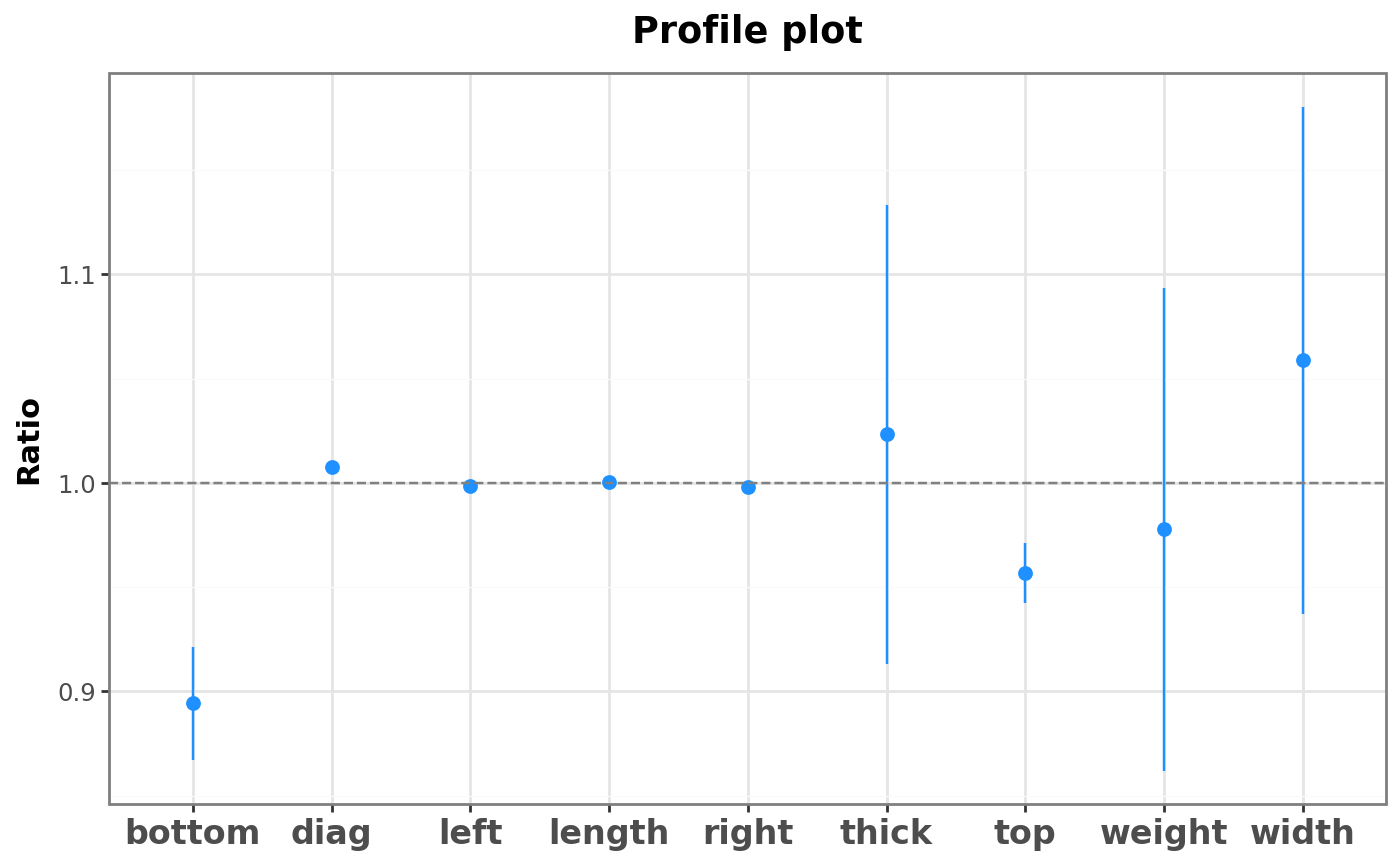

In [21]:
p = (ggplot(bf, aes(x = "variable", y = "mean")) +
        geom_pointrange(aes(ymin = "lower", ymax = "upper"), color = "dodgerblue") +
        geom_hline(yintercept = 1, linetype = "dashed", color = "gray") +
        labs(x = "", y = "Ratio", title = "Profile plot") +
        theme_bw() +
        theme(plot_title = element_text(ha = "center",
                                        weight = "bold",
                                        margin = {"b":5}),
              axis_title_x = element_text(weight = "bold"),
              axis_title_y = element_text(weight = "bold", rotation = 90),
              axis_text_x = element_text(size = 12, weight = "bold"),
              legend_title = element_text(ha = "center", weight = "bold"),
              legend_text = element_text(ha = "center"),
              strip_text = element_text(ha = "center", weight = "bold",
                                        margin = {"t":2, "r":3, "b":3, "l":3}),
              plot_subtitle = element_text(ha = "center", weight = "bold",
                                        size = 10, margin = {"b":5})) +
        theme(figure_size = (7, 7*0.618)))
p

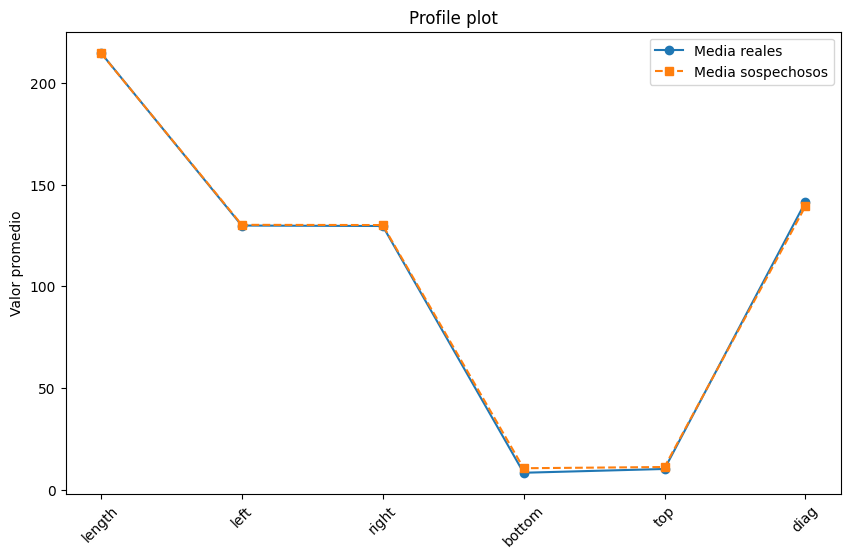

In [22]:
mean_real = df_real[selected_features].mean()
mean_fake = df_fake[selected_features].mean()

plt.figure(figsize=(10,6))
plt.plot(mean_real.index, mean_real.values, marker='o', label="Media reales")
plt.plot(mean_fake.index, mean_fake.values, marker='s', linestyle="--", label="Media sospechosos")
plt.xticks(rotation=45)
plt.ylabel("Valor promedio")
plt.title("Profile plot")
plt.legend()
plt.show()

8. Con base en todos los resultados que has obtenido, ¿cuál crees que sea la característica más relevante de un billete que ayude a detectar un billete falso?

Esto se debe a que:

* En el análisis, diag mostró los valores de covarianza más grandes.

* En la gráfica, aunque varias variables tienen dispersión, diag es la que mantiene un comportamiento más consistente y claramente separado del valor de referencia (línea de razón = 1).

* Aunque top, width y thick también presentan variaciones notables, sus intervalos de confianza son amplios, lo que genera mayor incertidumbre.

En conclusión: la medida “diag” es la característica más relevante para detectar un billete falso, ya que es donde la diferencia entre billetes auténticos y falsos se marca con mayor claridad.